In [ ]:
import matplotlib.pyplot as plt
from mplsoccer import Pitch, VerticalPitch, FontManager, PyPizza
import polars as pl
from pathlib import Path
from matplotlib.colors import LinearSegmentedColormap
from highlight_text import fig_text

# Notebook lives at eda/experiments/ — go up two levels to reach repo root
DATA_DIR = Path("../..") / "data"

## Basic Pitch Layout

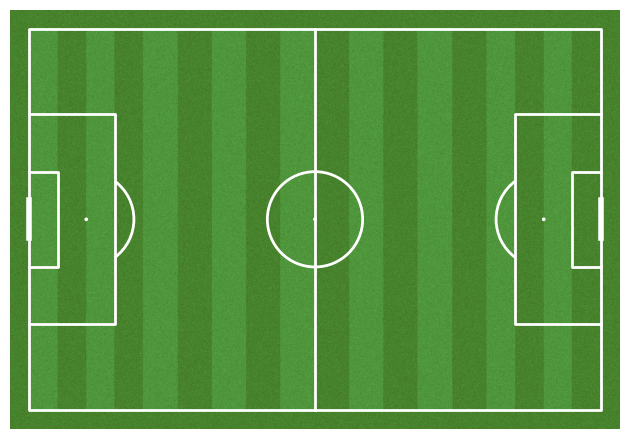

In [2]:
pitch = Pitch(pitch_color='grass', line_color='white', stripe=True)
fig, ax = pitch.draw()

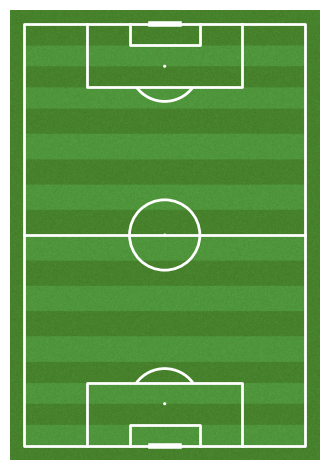

In [3]:
pitch = VerticalPitch(pitch_color='grass', line_color='white', stripe=True)
fig, ax = pitch.draw()

In [ ]:
events = pl.read_parquet(DATA_DIR / "Statsbomb" / "events.parquet")

# Processed CSVs
touch_share        = pl.read_csv(DATA_DIR / "processed" / "positional_touch_share.csv")
prog_actions_share = pl.read_csv(DATA_DIR / "processed" / "positional_progressive_actions_share.csv")
prog_dist_share    = pl.read_csv(DATA_DIR / "processed" / "positional_progressive_distance_share.csv")
wing_vs_central    = pl.read_csv(DATA_DIR / "processed" / "positional_wing_vs_central_progression_share.csv")
xg_parity          = pl.read_csv(DATA_DIR / "processed" / "xg_parity_matches.csv")

print(f"events:           {events.shape}")
print(f"touch_share:      {touch_share.shape}")
print(f"prog_actions:     {prog_actions_share.shape}")
print(f"prog_dist:        {prog_dist_share.shape}")
print(f"wing_vs_central:  {wing_vs_central.shape}")
print(f"xg_parity:        {xg_parity.shape}")

## Hexbin and KDE Plot (Action Distribution)

In [5]:
# Barcelona vs Deportive Alaves - Match ID 15946
ba_events = events.filter(pl.col("match_id") == 15946)

# Sergio Busquets in game 15946 - Player ID 5203
player_events = ba_events.filter(pl.col("player_id") == 5203)

In [6]:
player_passes = player_events.filter(pl.col("type") == "Pass")
player_passes.shape

flamingo_cmap = LinearSegmentedColormap.from_list("Flamingo - 10 colors",
                                                  ['#e3aca7', '#c03a1d'], N=10)

Text(0.5, 0.7, 'Sergio Busquets Pass Location Map')

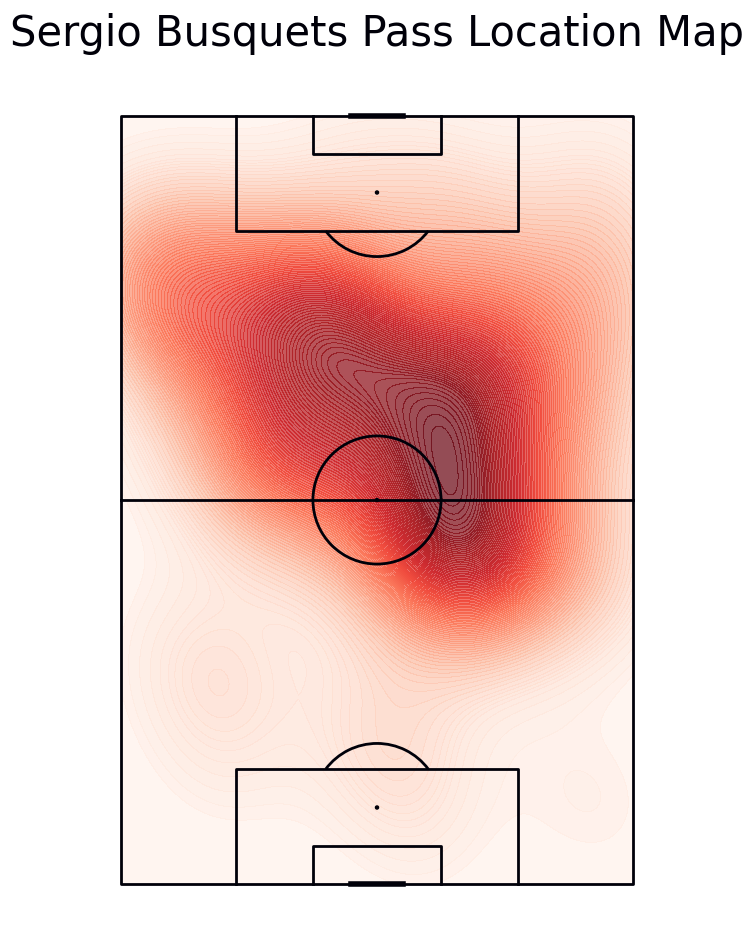

In [7]:
pitch = VerticalPitch(line_color='#000009', line_zorder=2, pitch_color='white')
fig, axs = pitch.grid(figheight=10, title_height=0.08, endnote_space=0,
                      title_space=0,
                      # Turn off the endnote/title axis. I usually do this after
                      # I am happy with the chart layout and text placement
                      axis=False,
                      grid_height=0.82, endnote_height=0.03)

kde_win = pitch.kdeplot(player_passes['pass_end_location_x'], player_passes['pass_end_location_y'], ax=axs['pitch'],
                           fill=True, levels=100, thresh=0,
                           cmap='Reds', alpha=0.7)

axs['title'].text(0.5, 0.7, "Sergio Busquets Pass Location Map", color='#000009',
                  va='center', ha='center', fontsize=30) 

Text(0.5, 0.7, 'Sergio Busquets Pass Location Map')

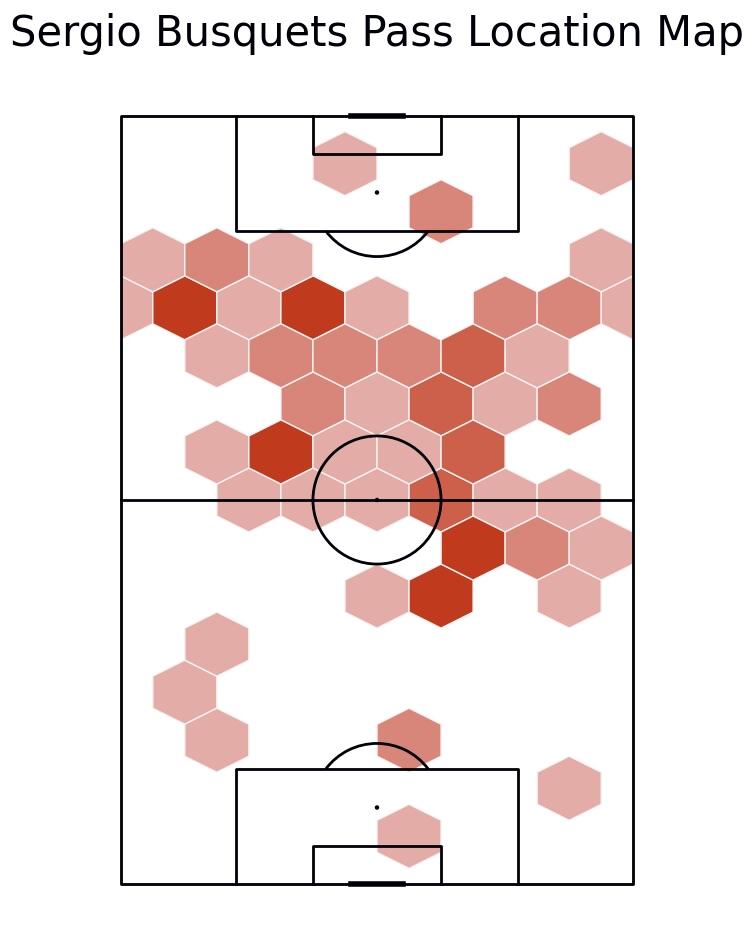

In [8]:
# Hexbin
flamingo_cmap = LinearSegmentedColormap.from_list("Flamingo - 10 colors",
                                                  ['#e3aca7', '#c03a1d'], N=10)

pitch = VerticalPitch(line_color='#000009', line_zorder=2, pitch_color='white')
fig, axs = pitch.grid(figheight=10, title_height=0.08, endnote_space=0,
                      title_space=0,
                      # Turn off the endnote/title axis. I usually do this after
                      # I am happy with the chart layout and text placement
                      axis=False,
                      grid_height=0.82, endnote_height=0.03)
hexmap = pitch.hexbin(player_passes['pass_end_location_x'], player_passes['pass_end_location_y'], ax=axs['pitch'], edgecolors='#f4f4f4',
                      gridsize=(8, 8), cmap=flamingo_cmap)

axs['title'].text(0.5, 0.7, "Sergio Busquets Pass Location Map", color='#000009',
                  va='center', ha='center', fontsize=30) 

## Pizza Plot

In [9]:
# parameter list
params = [
    "Touches", "Positional Touch Share", "Passes", "Forward Pass Progression", "xA",
    "Total Carry Distance", "Progressive Carry Distance", "Carries into Final Third", "Goal Creating Actions",  "xT"]

# Fake Data
values = [97, 88, 85, 76, 69, 35, 32, 70, 23, 65]

In [10]:
font_normal = FontManager('https://raw.githubusercontent.com/googlefonts/roboto/main/'
                          'src/hinted/Roboto-Regular.ttf')
font_italic = FontManager('https://raw.githubusercontent.com/googlefonts/roboto/main/'
                          'src/hinted/Roboto-Italic.ttf')
font_bold = FontManager('https://raw.githubusercontent.com/google/fonts/main/apache/robotoslab/'
                        'RobotoSlab[wght].ttf')

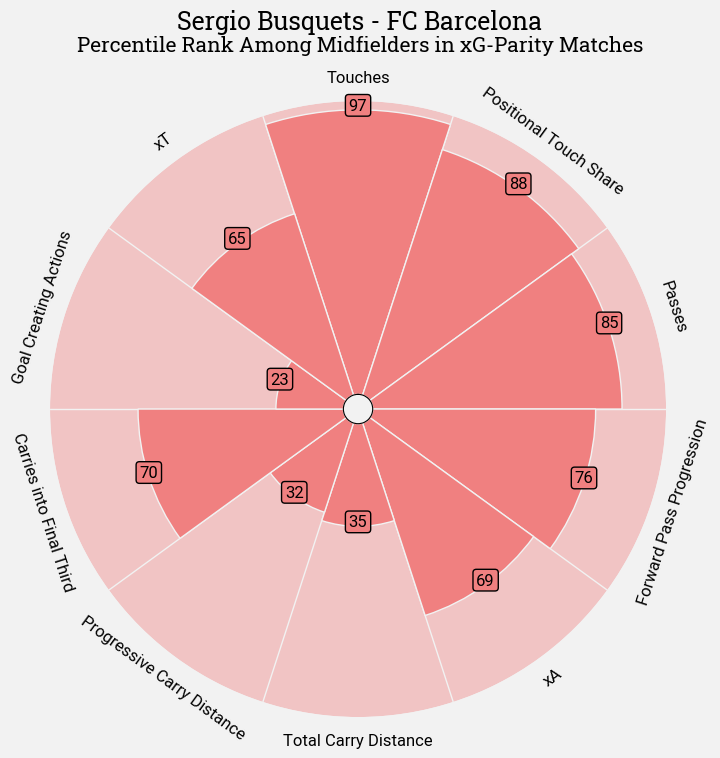

In [11]:
# instantiate PyPizza class
baker = PyPizza(
    params=params,                  # list of parameters
    straight_line_color="#F2F2F2",  # color for straight lines
    straight_line_lw=1,             # linewidth for straight lines
    last_circle_lw=0,               # linewidth of last circle
    other_circle_lw=0,              # linewidth for other circles
)

# plot pizza
fig, ax = baker.make_pizza(
    values,                                      # list of values
    figsize=(8, 8),                              # adjust figsize according to your need
    color_blank_space="same",   # use same color to fill blank space
    blank_alpha=0.4,                             # alpha for blank-space colors
    kwargs_slices=dict(
        facecolor="lightcoral", edgecolor="#F2F2F2",
        zorder=2, linewidth=1
    ),                                           # values to be used when plotting slices
    kwargs_params=dict(
        color="#000000", fontsize=12,
        fontproperties=font_normal.prop, va="center"
    ),                                           # values to be used when adding parameter
    kwargs_values=dict(
        color="#000000", fontsize=12,
        fontproperties=font_normal.prop, zorder=3,
        bbox=dict(
            edgecolor="#000000", facecolor="lightcoral",
            boxstyle="round,pad=0.2", lw=1
        )
    )                                            # values to be used when adding parameter-values
)

# add title
fig.text(
    0.515, 0.97, "Sergio Busquets - FC Barcelona", size=18,
    ha="center", fontproperties=font_bold.prop, color="#000000"
)

# add subtitle
fig.text(
    0.515, 0.942,
    "Percentile Rank Among Midfielders in xG-Parity Matches",
    size=15,
    ha="center", fontproperties=font_bold.prop, color="#000000"
)

# add credits
#CREDIT_1 = "data: statsbomb viz fbref"
#CREDIT_2 = "inspired by: @Worville, @FootballSlices, @somazerofc & @Soumyaj15209314"

#fig.text(
#    0.99, 0.005, f"{CREDIT_1}\n{CREDIT_2}", size=9,
#    fontproperties=font_italic.prop, color="#000000",
#    ha="right"
#)

plt.show()

In [12]:
# parameter list
params = [
    "Touches", "Positional Touch Share", "Passes", "Forward Pass Progression", "xA",
    "Total Carry Distance", "Progressive Carry Distance", "Carries into Final Third", "Goal Creating Actions",  "xT"]

# Fake Data
values_wins = [97, 88, 85, 76, 69, 35, 32, 70, 23, 65]
values_nonwins = [89, 80, 78, 52, 60, 61, 65, 80, 42, 55]

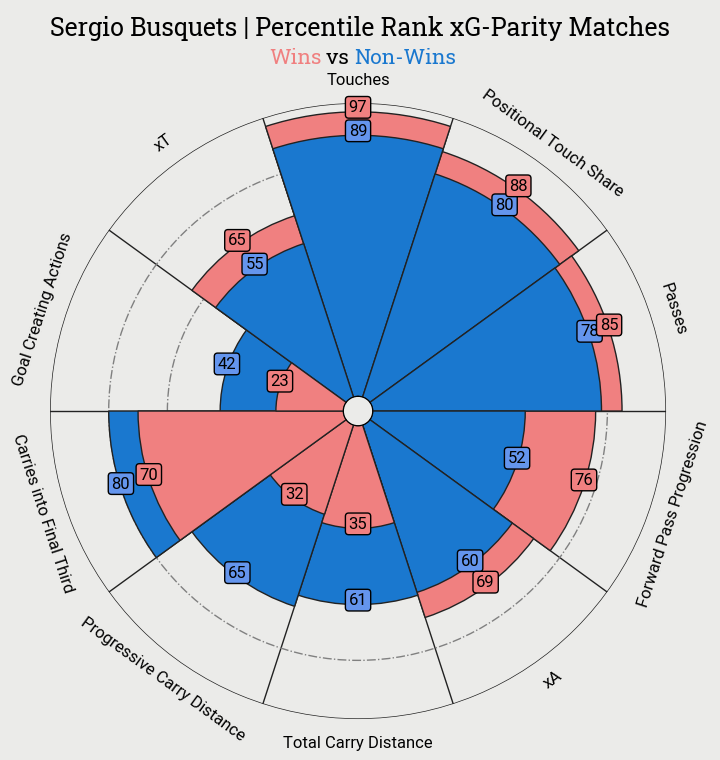

In [13]:

# instantiate PyPizza class
baker = PyPizza(
    params=params,                  # list of parameters
    background_color="#EBEBE9",     # background color
    straight_line_color="#222222",  # color for straight lines
    straight_line_lw=1,             # linewidth for straight lines
    last_circle_lw=1,               # linewidth of last circle
    last_circle_color="#222222",    # color of last circle
    other_circle_ls="-.",           # linestyle for other circles
    other_circle_lw=1               # linewidth for other circles
)

# plot pizza
fig, ax = baker.make_pizza(
    values_nonwins,                     # list of values
    compare_values=values_wins,    # comparison values
    figsize=(8, 8),             # adjust figsize according to your need
    kwargs_slices=dict(
        facecolor="#1A78CF", edgecolor="#222222",
        zorder=2, linewidth=1
    ),                          # values to be used when plotting slices
    kwargs_compare=dict(
        facecolor="lightcoral", edgecolor="#222222",
        zorder=2, linewidth=1,
    ),
    kwargs_params=dict(
        color="#000000", fontsize=12,
        fontproperties=font_normal.prop, va="center"
    ),                          # values to be used when adding parameter
    kwargs_values=dict(
        color="#000000", fontsize=12,
        fontproperties=font_normal.prop, zorder=3,
        bbox=dict(
            edgecolor="#000000", facecolor="cornflowerblue",
            boxstyle="round,pad=0.2", lw=1
        )
    ),                          # values to be used when adding parameter-values labels
    kwargs_compare_values=dict(
        color="#000000", fontsize=12, fontproperties=font_normal.prop, zorder=3,
        bbox=dict(edgecolor="#000000", facecolor="lightcoral", boxstyle="round,pad=0.2", lw=1)
    ),                          # values to be used when adding parameter-values labels
)

from highlight_text import fig_text

# --- Add Title ---
fig_text(
    0.515, 0.99,
    "Sergio Busquets | Percentile Rank xG-Parity Matches",
    ha="center", 
    fontsize=18, 
    fontproperties=font_bold.prop, 
    color="#000000"
)

# --- Add Subtitle with Colored Highlights ---
fig_text(
    0.515, 0.95, 
    " <Wins> vs <Non-Wins>", 
    highlight_textprops=[
        {"color": 'lightcoral'}, # Color for the first <...>
        {"color": '#1A78CF'}  # Color for the second <...>
    ],
    fontsize=15,
    ha="center", 
    fontproperties=font_bold.prop, 
    color="#000000"
)

# add credits
#CREDIT_1 = "data: statsbomb viz fbref"
#CREDIT_2 = "inspired by: @Worville, @FootballSlices, @somazerofc & @Soumyaj15209314"

#fig.text(
#    0.99, 0.005, f"{CREDIT_1}\n{CREDIT_2}", size=9,
#    fontproperties=font_italic.prop, color="#000000",
#    ha="right"
#)

plt.show()

## Positional Group Pizza Plots — Barcelona: Wins vs Non-Wins

Percentile ranks computed across all teams in the processed dataset, grouped into three positional units. Each plot compares Barcelona's average profile in **wins** (coral) vs **non-wins** (blue) for that unit.

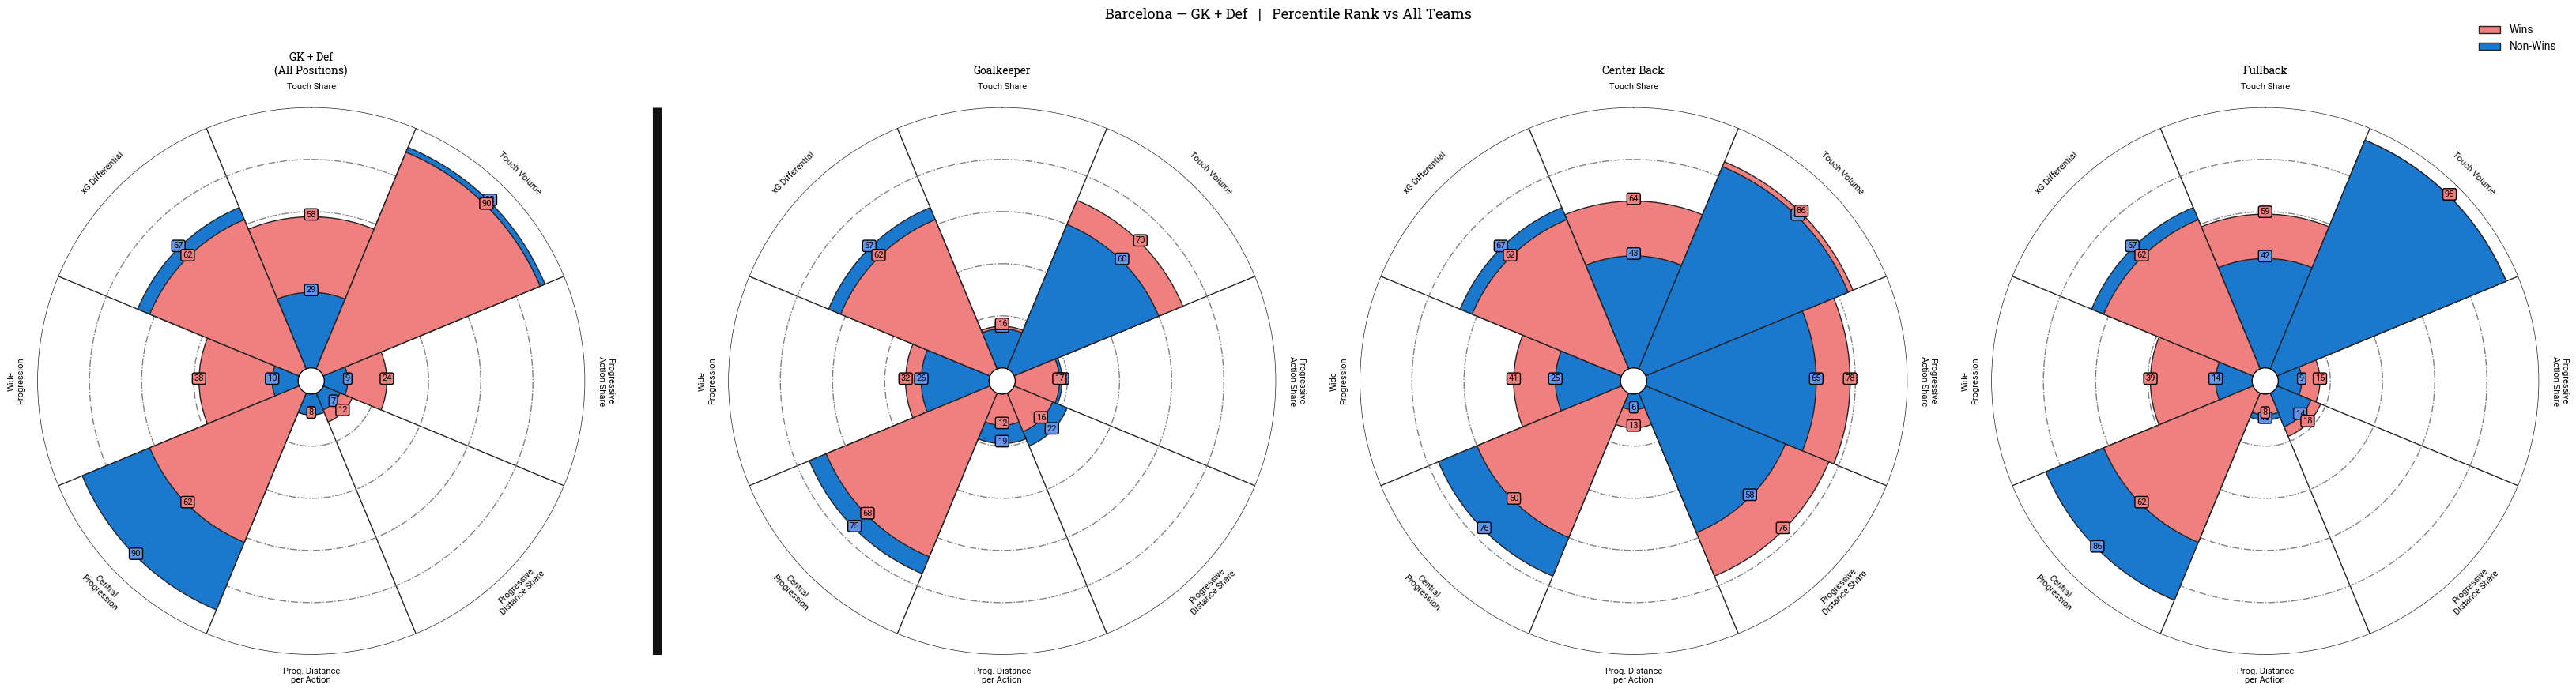

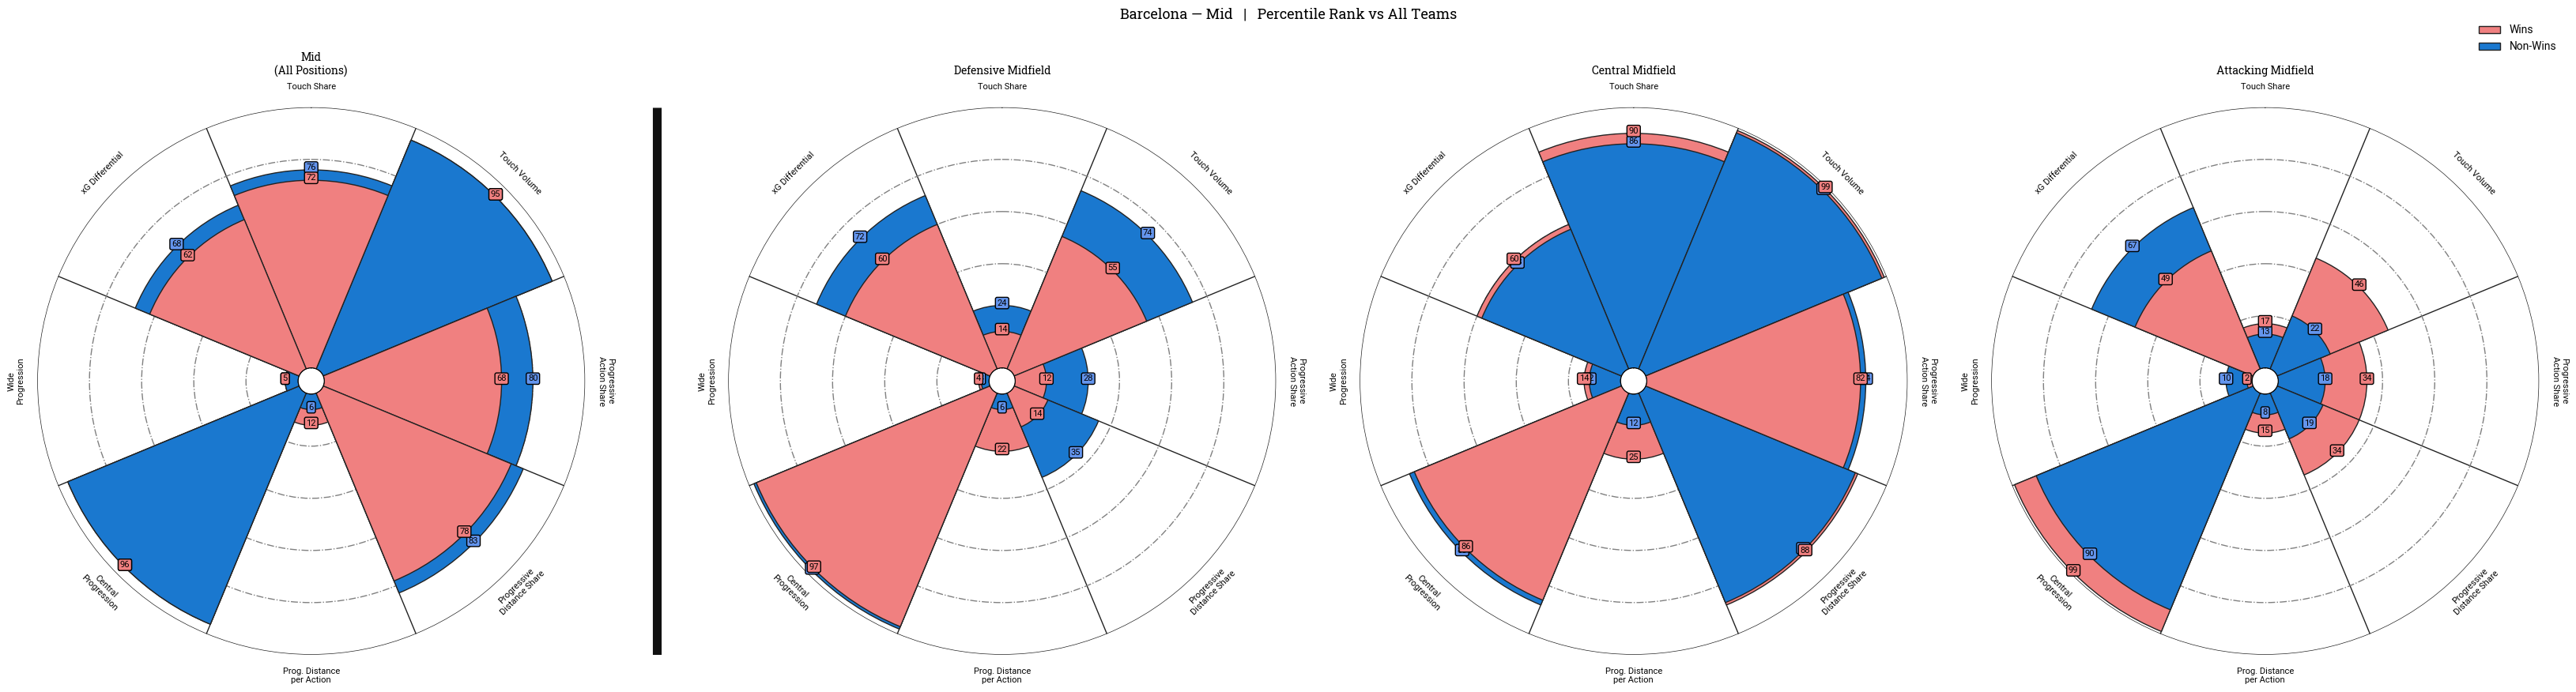

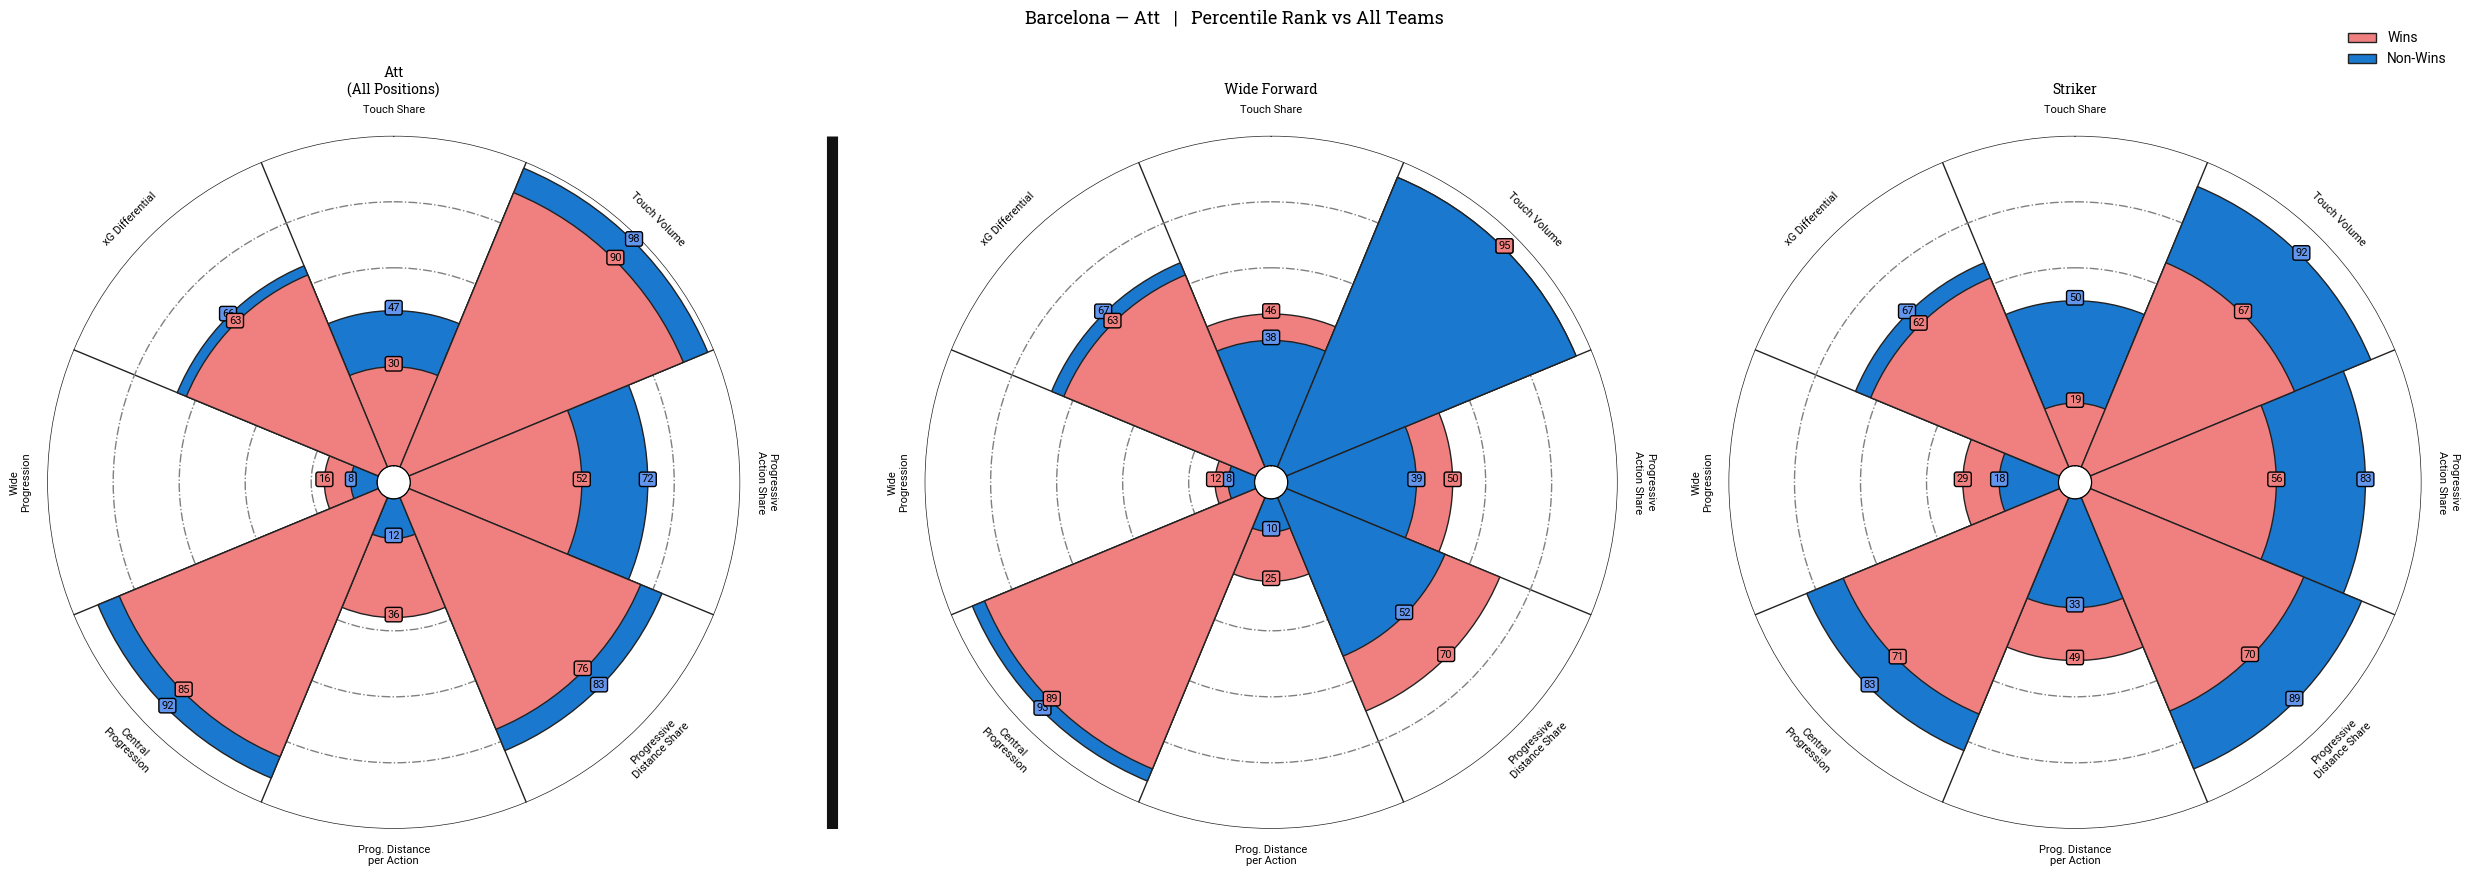

In [24]:
import numpy as np
import matplotlib.gridspec as gridspec
from matplotlib.patches import Patch

TEAM = "Barcelona"

# --- Build joined base table ---
base = (
    touch_share
    .join(
        prog_actions_share.select(["match_id","team","position_bin","progressive_actions","progressive_share"]),
        on=["match_id","team","position_bin"], how="left"
    )
    .join(
        prog_dist_share.select(["match_id","team","position_bin","progressive_distance","progressive_distance_share"]),
        on=["match_id","team","position_bin"], how="left"
    )
    .join(
        wing_vs_central.select(["match_id","team","position_bin","central_progression_share","wide_progression_share"]),
        on=["match_id","team","position_bin"], how="left"
    )
    .join(
        xg_parity.select(["match_id","team","xg_diff"]),
        on=["match_id","team"], how="left"
    )
    .with_columns(
        (pl.col("progressive_distance") / pl.col("progressive_actions").cast(pl.Float64))
        .alias("prog_dist_per_action")
    )
    .with_columns(
        pl.col("position_bin").replace({
            "Goalkeeper":         "GK + Def",
            "Center Back":        "GK + Def",
            "Fullback":           "GK + Def",
            "Defensive Midfield": "Mid",
            "Central Midfield":   "Mid",
            "Attacking Midfield": "Mid",
            "Wide Forward":       "Att",
            "Striker":            "Att",
        }).alias("pos_group")
    )
)

METRICS = [
    "touch_share", "touches", "progressive_share", "progressive_distance_share",
    "prog_dist_per_action", "central_progression_share", "wide_progression_share", "xg_diff",
]
METRIC_LABELS = [
    "Touch Share", "Touch Volume", "Progressive\nAction Share", "Progressive\nDistance Share",
    "Prog. Distance\nper Action", "Central\nProgression", "Wide\nProgression", "xG Differential",
]

# --- Aggregate at position-GROUP and position-BIN level ---
agg_exprs   = [pl.col(m).mean().alias(m) for m in METRICS]
grouped_grp = base.group_by(["team", "pos_group",    "outcome_binary"]).agg(agg_exprs)
grouped_bin = base.group_by(["team", "position_bin", "outcome_binary"]).agg(agg_exprs)

def _rank(subset, team_name):
    team_row = subset.filter(pl.col("team") == team_name)
    if team_row.is_empty():
        return [50] * len(METRICS)
    percentiles = []
    for m in METRICS:
        col_vals = subset[m].drop_nulls().to_list()
        team_val = team_row[m][0]
        if team_val is None or len(col_vals) == 0:
            percentiles.append(50)
        else:
            percentiles.append(int(round(sum(v <= team_val for v in col_vals) / len(col_vals) * 100)))
    return percentiles

def get_pct_group(team_name, pos_grp, outcome):
    return _rank(
        grouped_grp.filter((pl.col("pos_group") == pos_grp) & (pl.col("outcome_binary") == outcome)),
        team_name
    )

def get_pct_bin(team_name, pos_bin, outcome):
    return _rank(
        grouped_bin.filter((pl.col("position_bin") == pos_bin) & (pl.col("outcome_binary") == outcome)),
        team_name
    )

# --- Shared pizza style ---
PIZZA_KWARGS = dict(
    background_color="#EBEBE9",
    straight_line_color="#222222", straight_line_lw=1,
    last_circle_lw=1, last_circle_color="#222222",
    other_circle_ls="-.", other_circle_lw=1,
)
KW_NONWIN = dict(facecolor="#1A78CF",    edgecolor="#222222", zorder=2, linewidth=1)
KW_WIN    = dict(facecolor="lightcoral", edgecolor="#222222", zorder=2, linewidth=1)
KW_PARAMS = dict(color="#000000", fontsize=8, fontproperties=font_normal.prop, va="center")
KW_VALS   = dict(color="#000000", fontsize=8, fontproperties=font_normal.prop, zorder=3,
                  bbox=dict(edgecolor="#000000", facecolor="cornflowerblue", boxstyle="round,pad=0.2", lw=1))
KW_CVALS  = dict(color="#000000", fontsize=8, fontproperties=font_normal.prop, zorder=3,
                  bbox=dict(edgecolor="#000000", facecolor="lightcoral",     boxstyle="round,pad=0.2", lw=1))

POS_BINS_BY_GROUP = {
    "GK + Def": ["Goalkeeper",         "Center Back",      "Fullback"          ],
    "Mid":      ["Defensive Midfield",  "Central Midfield", "Attacking Midfield"],
    "Att":      ["Wide Forward",        "Striker"                               ],
}

# --- One wide figure per position group ---
for pg, bins in POS_BINS_BY_GROUP.items():
    n_ind = len(bins)

    # Column layout: [group pizza | bold separator | individual pizzas...]
    width_ratios = [10, 0.5] + [10] * n_ind
    n_cols       = 2 + n_ind

    fig = plt.figure(figsize=(8 * (1 + n_ind) + 1, 9))
    gs  = gridspec.GridSpec(
        1, n_cols,
        width_ratios=width_ratios,
        figure=fig,
        left=0.01, right=0.99, wspace=0.06
    )

    # — Group-level pizza (left panel) — polar axes required by PyPizza
    ax_grp = fig.add_subplot(gs[0, 0], projection="polar")
    PyPizza(params=METRIC_LABELS, **PIZZA_KWARGS).make_pizza(
        get_pct_group(TEAM, pg, "Non-Win"),
        compare_values=get_pct_group(TEAM, pg, "Win"),
        ax=ax_grp,
        kwargs_slices=KW_NONWIN, kwargs_compare=KW_WIN,
        kwargs_params=KW_PARAMS, kwargs_values=KW_VALS, kwargs_compare_values=KW_CVALS,
    )
    ax_grp.set_title(f"{pg}\n(All Positions)", fontproperties=font_bold.prop, fontsize=10, pad=30)

    # — Bold vertical separator —
    ax_sep = fig.add_subplot(gs[0, 1])
    ax_sep.axvline(0.5, color="#111111", linewidth=8, solid_capstyle="butt")
    ax_sep.set_xlim(0, 1)
    ax_sep.axis("off")

    # — Individual position-bin pizzas (right panels) —
    for i, pos_bin in enumerate(bins):
        ax_ind = fig.add_subplot(gs[0, i + 2], projection="polar")
        PyPizza(params=METRIC_LABELS, **PIZZA_KWARGS).make_pizza(
            get_pct_bin(TEAM, pos_bin, "Non-Win"),
            compare_values=get_pct_bin(TEAM, pos_bin, "Win"),
            ax=ax_ind,
            kwargs_slices=KW_NONWIN, kwargs_compare=KW_WIN,
            kwargs_params=KW_PARAMS, kwargs_values=KW_VALS, kwargs_compare_values=KW_CVALS,
        )
        ax_ind.set_title(pos_bin, fontproperties=font_bold.prop, fontsize=10, pad=30)

    # — Figure-level title and legend —
    fig.suptitle(
        f"Barcelona — {pg}   |   Percentile Rank vs All Teams",
        fontproperties=font_bold.prop, fontsize=13, y=1.02
    )
    legend_elements = [
        Patch(facecolor="lightcoral", edgecolor="#222222", label="Wins"),
        Patch(facecolor="#1A78CF",    edgecolor="#222222", label="Non-Wins"),
    ]
    fig.legend(
        handles=legend_elements,
        loc="upper right", bbox_to_anchor=(0.99, 1.01),
        fontsize=10, frameon=False, prop=font_normal.prop
    )

    plt.show()

## Midfield Impact Figures

Two high-impact single/dual metric views for the midfield positional group.

- **Dumbbell Plot** — central vs wide progression share by position bin. Compares Barcelona wins (coral), Barcelona non-wins (blue), and the league average (grey diamond) across all 8 positions. Shows how Barcelona's dominant central style shifts by result.
- **Scatter** — relationship between midfield touch share (involvement) and progressive action share (output), all teams with ≥5 matches per outcome.

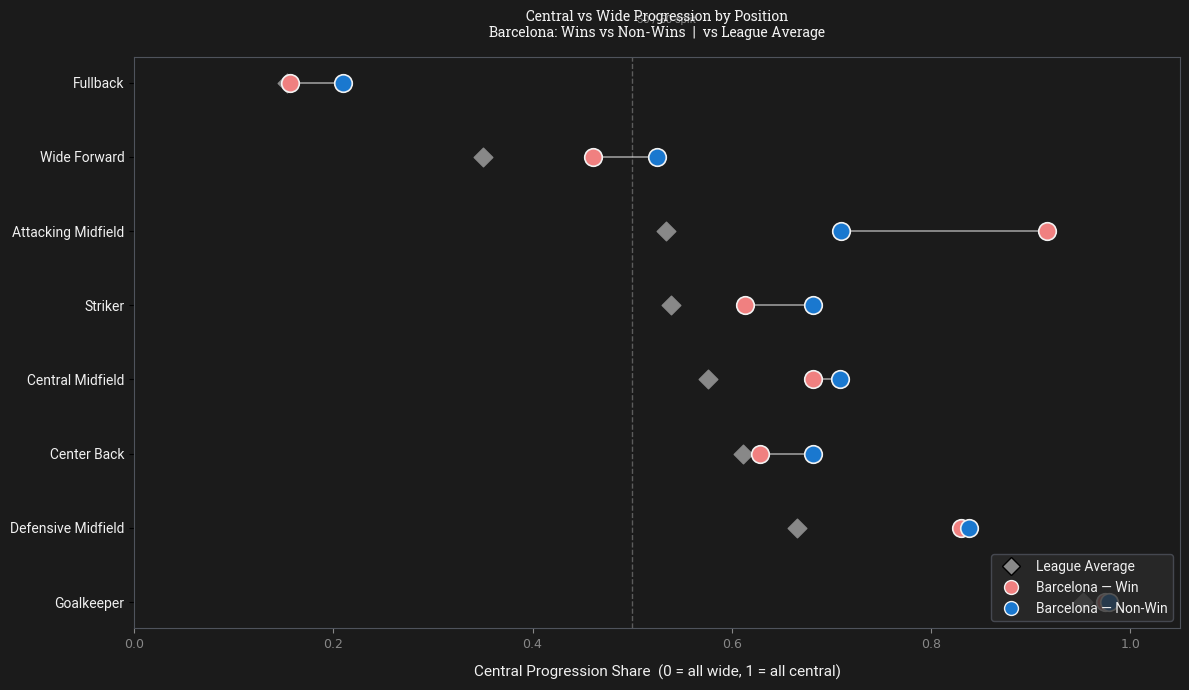

In [27]:
# ── Figure 1: Dumbbell — Central vs Wide Progression by Position ──────────────
# Compares Barcelona (wins/non-wins) vs league average for central_progression_share
# across all 8 position bins. Positions sorted by league avg centrality.

BG    = "#1B1B1B"
WHITE = "#F2F2F2"
GREY  = "#888888"
CORAL = "lightcoral"
BLUE  = "#1A78CF"

# League average central progression per position (all teams)
league_agg = (
    wing_vs_central
    .group_by("position_bin")
    .agg(pl.col("central_progression_share").mean().alias("central"))
    .sort("central", descending=True)
)
order      = league_agg["position_bin"].to_list()
league_avg = dict(zip(league_agg["position_bin"].to_list(), league_agg["central"].to_list()))

# Barcelona per outcome
barca_agg = (
    wing_vs_central
    .filter(pl.col("team") == "Barcelona")
    .group_by(["position_bin", "outcome_binary"])
    .agg(pl.col("central_progression_share").mean().alias("central"))
)
barca_win    = dict(zip(
    barca_agg.filter(pl.col("outcome_binary") == "Win")["position_bin"].to_list(),
    barca_agg.filter(pl.col("outcome_binary") == "Win")["central"].to_list()
))
barca_nonwin = dict(zip(
    barca_agg.filter(pl.col("outcome_binary") == "Non-Win")["position_bin"].to_list(),
    barca_agg.filter(pl.col("outcome_binary") == "Non-Win")["central"].to_list()
))

fig, ax = plt.subplots(figsize=(12, 7), facecolor=BG)
ax.set_facecolor(BG)

for i, pos in enumerate(order):
    lv = league_avg[pos]
    bw = barca_win.get(pos)
    bn = barca_nonwin.get(pos)

    # Connector between Barcelona Win and Non-Win
    if bw is not None and bn is not None:
        ax.plot([bw, bn], [i, i], color=WHITE, lw=1.4, alpha=0.5, zorder=2)

    # League avg — grey diamond
    ax.scatter(lv, i, color=GREY, s=90, zorder=3, marker='D')

    # Barcelona Win — coral circle
    if bw is not None:
        ax.scatter(bw, i, color=CORAL, s=160, zorder=4, edgecolors=WHITE, linewidths=1.2)

    # Barcelona Non-Win — blue circle
    if bn is not None:
        ax.scatter(bn, i, color=BLUE, s=160, zorder=4, edgecolors=WHITE, linewidths=1.2)

# 50% reference line (equal central / wide split)
ax.axvline(0.5, color=GREY, lw=1, ls='--', alpha=0.6, zorder=1)
ax.text(0.505, len(order) - 0.2, "50 / 50 split", color=GREY, fontsize=8,
        fontproperties=font_normal.prop)

# Y-axis labels
ax.set_yticks(range(len(order)))
ax.set_yticklabels(order, color=WHITE, fontsize=11, fontproperties=font_normal.prop)
ax.tick_params(axis='x', colors=GREY, labelsize=9)
ax.set_xlim(0, 1.05)
ax.set_xlabel("Central Progression Share  (0 = all wide, 1 = all central)",
              color=WHITE, fontsize=11, fontproperties=font_normal.prop, labelpad=10)

for spine in ax.spines.values():
    spine.set_edgecolor("#4F535C")
ax.set_facecolor(BG)

# Legend
from matplotlib.lines import Line2D
legend_elements = [
    Line2D([0], [0], marker='D', color='none', markerfacecolor=GREY,   markersize=9,  label='League Average'),
    Line2D([0], [0], marker='o', color='none', markerfacecolor=CORAL,  markersize=10, markeredgecolor=WHITE, label='Barcelona — Win'),
    Line2D([0], [0], marker='o', color='none', markerfacecolor=BLUE,   markersize=10, markeredgecolor=WHITE, label='Barcelona — Non-Win'),
]
ax.legend(handles=legend_elements, facecolor="#2B2B2B", edgecolor="#4F535C",
          labelcolor=WHITE, fontsize=10, prop=font_normal.prop, loc="lower right")

ax.set_title(
    "Central vs Wide Progression by Position\n"
    "Barcelona: Wins vs Non-Wins  |  vs League Average",
    color=WHITE, fontsize=13, pad=14, fontproperties=font_bold.prop
)

plt.tight_layout()
plt.show()

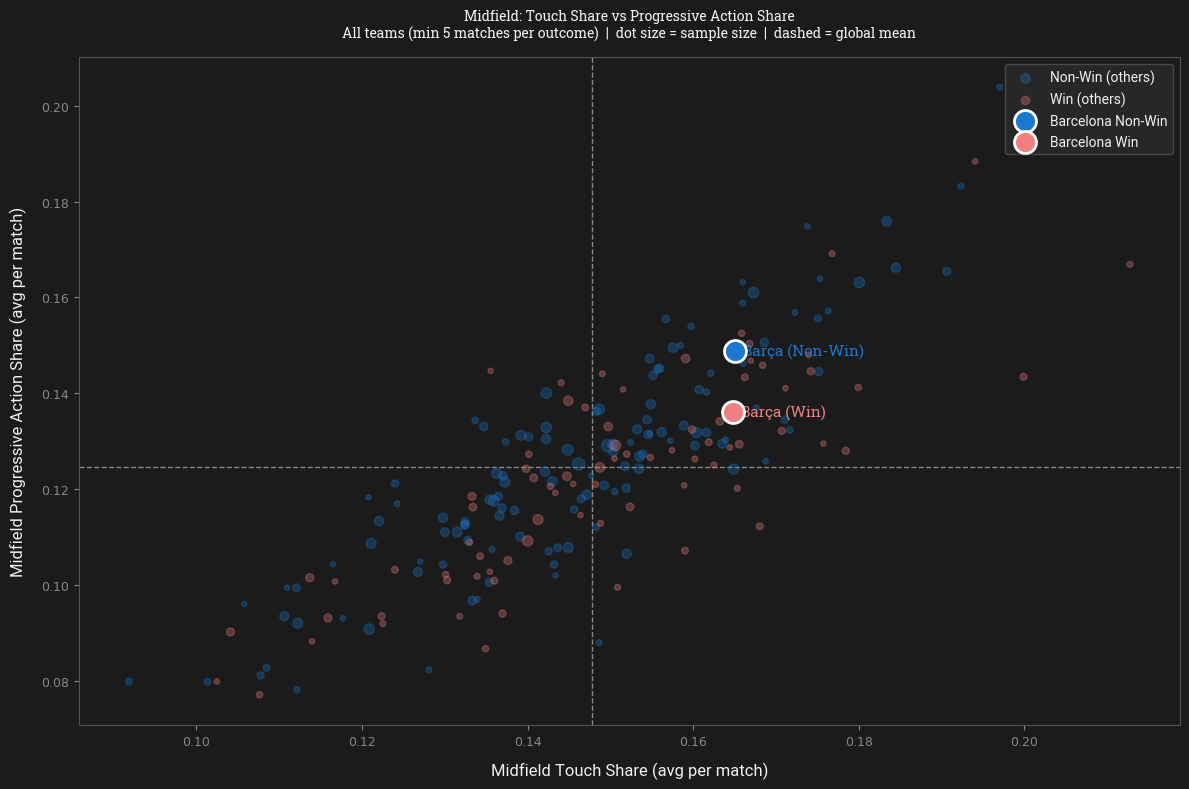

In [26]:
# ── Figure 2: Scatter — Touch Share × Progressive Action Share (Midfield) ─────
# All teams with ≥5 matches per outcome. Dot size = sample size. Barcelona labelled.

all_mid = (
    touch_share
    .join(
        prog_actions_share.select(["match_id","team","position_bin","progressive_share"]),
        on=["match_id","team","position_bin"], how="left"
    )
    .filter(pl.col("position_bin").is_in(["Defensive Midfield","Central Midfield","Attacking Midfield"]))
    .group_by(["team","outcome_binary"])
    .agg(
        pl.col("touch_share").mean().alias("touch_share"),
        pl.col("progressive_share").mean().alias("progressive_share"),
        pl.len().alias("n"),
    )
    .filter(pl.col("n") >= 5)
).to_pandas()

win_df    = all_mid[all_mid["outcome_binary"]=="Win"]
nonwin_df = all_mid[all_mid["outcome_binary"]=="Non-Win"]

fig, ax = plt.subplots(figsize=(12, 8), facecolor="#1B1B1B")
ax.set_facecolor("#1B1B1B")

# All other teams — semi-transparent
ax.scatter(nonwin_df[nonwin_df["team"]!="Barcelona"]["touch_share"],
           nonwin_df[nonwin_df["team"]!="Barcelona"]["progressive_share"],
           c="#1A78CF", alpha=0.3, s=nonwin_df[nonwin_df["team"]!="Barcelona"]["n"] * 3,
           zorder=2, label="Non-Win (others)")
ax.scatter(win_df[win_df["team"]!="Barcelona"]["touch_share"],
           win_df[win_df["team"]!="Barcelona"]["progressive_share"],
           c="lightcoral", alpha=0.3, s=win_df[win_df["team"]!="Barcelona"]["n"] * 3,
           zorder=2, label="Win (others)")

# Barcelona — solid with white edge
barca_nw = nonwin_df[nonwin_df["team"]=="Barcelona"]
barca_w  = win_df[win_df["team"]=="Barcelona"]
ax.scatter(barca_nw["touch_share"], barca_nw["progressive_share"],
           c="#1A78CF", s=250, zorder=5, edgecolors="white", linewidths=2, label="Barcelona Non-Win")
ax.scatter(barca_w["touch_share"],  barca_w["progressive_share"],
           c="lightcoral", s=250, zorder=5, edgecolors="white", linewidths=2, label="Barcelona Win")

for _, row in barca_w.iterrows():
    ax.annotate("  Barça (Win)",
                (row["touch_share"], row["progressive_share"]),
                color="lightcoral", fontsize=11, va="center",
                fontproperties=font_bold.prop)
for _, row in barca_nw.iterrows():
    ax.annotate("  Barça (Non-Win)",
                (row["touch_share"], row["progressive_share"]),
                color="#1A78CF", fontsize=11, va="center",
                fontproperties=font_bold.prop)

# Grand-mean reference lines
ax.axvline(all_mid["touch_share"].mean(), color="#888888", lw=1, ls="--", zorder=1)
ax.axhline(all_mid["progressive_share"].mean(), color="#888888", lw=1, ls="--", zorder=1)

ax.set_xlabel("Midfield Touch Share (avg per match)",
              color="#F2F2F2", fontsize=12, fontproperties=font_normal.prop, labelpad=10)
ax.set_ylabel("Midfield Progressive Action Share (avg per match)",
              color="#F2F2F2", fontsize=12, fontproperties=font_normal.prop, labelpad=10)
ax.tick_params(colors="#888888", labelsize=9)
for spine in ax.spines.values():
    spine.set_edgecolor("#4F535C")

ax.set_title(
    "Midfield: Touch Share vs Progressive Action Share\n"
    "All teams (min 5 matches per outcome)  |  dot size = sample size  |  dashed = global mean",
    color="#F2F2F2", fontsize=13, pad=14, fontproperties=font_bold.prop
)
ax.legend(facecolor="#2B2B2B", edgecolor="#4F535C", labelcolor="#F2F2F2",
          fontsize=9, prop=font_normal.prop)

plt.tight_layout()
plt.show()

## Animation (Probably Won't Need)

In [14]:
player_events_tenmin = player_events.filter(pl.col("minute") <= 9)

player_events_tenmin

id,index_num,period,minute,second,timestamp,duration,location_x,location_y,possession,possession_team_id,possession_team,out,off_camera,counterpress,under_pressure,type_id,type,match_id,team_id,team,player_id,player,position_id,position,play_pattern_id,play_pattern,shot_end_location_x,shot_end_location_y,shot_end_location_z,shot_statsbomb_xg,shot_outcome,shot_technique,shot_body_part,shot_type,shot_key_pass_id,shot_freeze_frame,…,dribble_overrun,dribble_no_touch,duel_type,duel_outcome,foul_committed_card,foul_committed_type,foul_committed_offensive,foul_committed_advantage,foul_committed_penalty,foul_won_defensive,foul_won_advantage,foul_won_penalty,goalkeeper_type,goalkeeper_outcome,goalkeeper_technique,goalkeeper_position,goalkeeper_body_part,goalkeeper_end_location_x,goalkeeper_end_location_y,clearance_body_part,clearance_aerial_won,clearance_head,clearance_left_foot,clearance_right_foot,interception_outcome,block_deflection,block_offensive,block_save_block,ball_recovery_offensive,ball_recovery_failure,miscontrol_aerial_won,substitution_replacement_id,substitution_replacement_name,substitution_outcome,fifty_fifty_outcome,bad_behaviour_card,injury_stoppage_in_chain
str,i32,i32,i32,i32,str,f32,f32,f32,i32,i32,str,bool,bool,bool,bool,i32,str,i32,i32,str,i32,str,i32,str,i32,str,f32,f32,f32,f32,str,str,str,str,str,str,…,bool,bool,str,str,str,str,bool,bool,bool,bool,bool,bool,str,str,str,str,str,f32,f32,str,bool,bool,bool,bool,str,bool,bool,bool,bool,bool,bool,i32,str,str,str,str,bool
"""be27cc25-92b5-4696-b43c-aad957…",11,1,0,7,"""00:00:07.152""",1.696529,33.599998,5.9,3,217,"""Barcelona""",false,false,false,true,30,"""Pass""",15946,217,"""Barcelona""",5203,"""Sergio Busquets i Burgos""",9,"""Right Defensive Midfield""",1,"""Regular Play""",null,null,null,null,null,null,null,null,null,null,…,false,false,null,null,null,null,false,false,false,false,false,false,null,null,null,null,null,null,null,null,false,false,false,false,null,false,false,false,false,false,false,null,null,null,null,null,false
"""8495291c-95ef-491d-834c-974d83…",68,1,1,16,"""00:01:16.595""",1.782612,79.0,74.400002,5,217,"""Barcelona""",false,false,false,false,30,"""Pass""",15946,217,"""Barcelona""",5203,"""Sergio Busquets i Burgos""",9,"""Right Defensive Midfield""",1,"""Regular Play""",null,null,null,null,null,null,null,null,null,null,…,false,false,null,null,null,null,false,false,false,false,false,false,null,null,null,null,null,null,null,null,false,false,false,false,null,false,false,false,false,false,false,null,null,null,null,null,false
"""6dc75c33-fcdb-496f-85fd-86efe8…",81,1,1,32,"""00:01:32.62""",null,77.5,24.1,5,217,"""Barcelona""",false,false,false,false,42,"""Ball Receipt*""",15946,217,"""Barcelona""",5203,"""Sergio Busquets i Burgos""",9,"""Right Defensive Midfield""",1,"""Regular Play""",null,null,null,null,null,null,null,null,null,null,…,false,false,null,null,null,null,false,false,false,false,false,false,null,null,null,null,null,null,null,null,false,false,false,false,null,false,false,false,false,false,false,null,null,null,null,null,false
"""d50aec76-9cc0-40a6-9eb5-6fd2a5…",82,1,1,32,"""00:01:32.62""",0.04,77.5,24.1,5,217,"""Barcelona""",false,false,false,false,43,"""Carry""",15946,217,"""Barcelona""",5203,"""Sergio Busquets i Burgos""",9,"""Right Defensive Midfield""",1,"""Regular Play""",null,null,null,null,null,null,null,null,null,null,…,false,false,null,null,null,null,false,false,false,false,false,false,null,null,null,null,null,null,null,null,false,false,false,false,null,false,false,false,false,false,false,null,null,null,null,null,false
"""22f4d181-fd17-4919-bce0-ee6de9…",83,1,1,32,"""00:01:32.66""",0.963959,78.099998,26.9,5,217,"""Barcelona""",false,false,false,false,30,"""Pass""",15946,217,"""Barcelona""",5203,"""Sergio Busquets i Burgos""",9,"""Right Defensive Midfield""",1,"""Regular Play""",null,null,null,null,null,null,null,null,null,null,…,false,false,null,null,null,null,false,false,false,false,false,false,null,null,null,null,null,null,null,nul

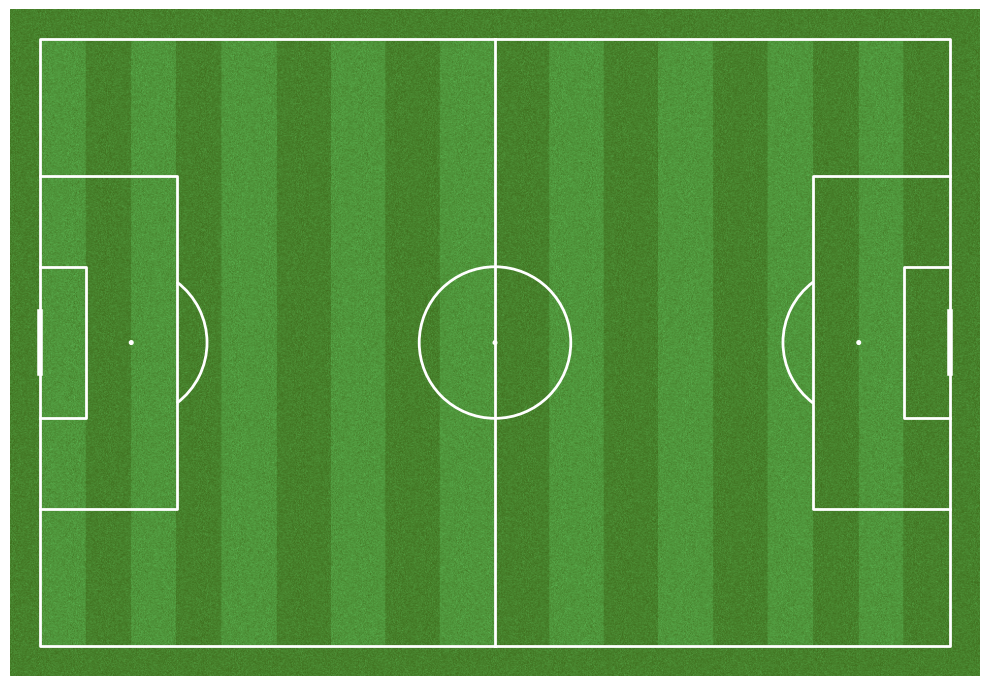

In [15]:
import pandas as pd
import numpy as np
import matplotlib.animation as animation
import matplotlib.pyplot as plt
from mplsoccer import Pitch
from IPython.display import HTML
import matplotlib as mpl

# 1. Increase the embedding limit to handle long sequences
mpl.rcParams['animation.embed_limit'] = 75.0 
plt.rcParams["animation.html"] = "jshtml" 

# 2. Data processing - Lowered frames slightly for memory efficiency
frames_per_event = 8 
animated_rows = []

for row in player_events_tenmin.iter_rows(named=True):
    start_x = row.get('location_x', 0.0) or 0.0
    start_y = row.get('location_y', 0.0) or 0.0
    
    event_type = row.get('type')
    if event_type == 'Pass':
        end_x = row.get('pass_end_location_x', start_x)
        end_y = row.get('pass_end_location_y', start_y)
    elif event_type == 'Carry':
        end_x = row.get('carry_end_location_x', start_x)
        end_y = row.get('carry_end_location_y', start_y)
    else:
        end_x, end_y = start_x, start_y

    end_x = float(end_x) if end_x is not None else float(start_x)
    end_y = float(end_y) if end_y is not None else float(start_y)

    ball_x = np.linspace(float(start_x), end_x, frames_per_event)
    ball_y = np.linspace(float(start_y), end_y, frames_per_event)
    
    if event_type == 'Carry':
        player_x, player_y = ball_x, ball_y
    else:
        player_x = np.full(frames_per_event, float(start_x))
        player_y = np.full(frames_per_event, float(start_y))
    
    m = row.get('minute', 0)
    s = row.get('second', 0)
    time_str = f"{m:02d}:{s:02d}"

    for i in range(frames_per_event):
        animated_rows.append({
            'ball_x': ball_x[i], 'ball_y': ball_y[i],
            'player_x': player_x[i], 'player_y': player_y[i],
            'type': event_type, 
            'time': time_str
        })

df_anim = pd.DataFrame(animated_rows)

# 3. Setup Pitch
pitch = Pitch(pitch_type='statsbomb', pitch_color='grass', line_color='white', stripe=True)
fig, ax = pitch.draw(figsize=(10, 7))

# Character (Blue) and Ball (White)
player, = ax.plot([], [], marker='o', ms=15, markerfacecolor='#0077ff', 
                  markeredgecolor='white', zorder=4)
ball, = ax.plot([], [], marker='o', ms=8, markerfacecolor='white', 
                markeredgecolor='black', lw=1, zorder=5)

# Event Tag Text
event_text = ax.text(2, 75, '', fontsize=15, color='white', 
                     fontweight='bold', bbox=dict(facecolor='black', alpha=0.5))

def animate(i):
    player.set_data([df_anim.iloc[i]['player_x']], [df_anim.iloc[i]['player_y']])
    ball.set_data([df_anim.iloc[i]['ball_x']], [df_anim.iloc[i]['ball_y']])
    
    e_type = df_anim.iloc[i]['type']
    e_time = df_anim.iloc[i]['time']
    event_text.set_text(f"TIME: {e_time} | EVENT: {e_type}")
    
    return player, ball, event_text

# 4. Create animation - Interval 60 for smoother viewing of longer clips
# anim = animation.FuncAnimation(fig, animate, frames=len(df_anim), interval=60, blit=True)

#plt.close()
#HTML(anim.to_jshtml())

In [17]:
#anim.save('experiments/viz_video.gif', writer='ffmpeg', fps=20)